In [15]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os 
import sys 
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import randint
import matplotlib.pyplot as plt
from boruta import BorutaPy

In [16]:
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats_na_dropped.geojson')
gdf = gpd.read_file(data_path)
print(len(gdf))

1929


In [17]:
class Runner:
    def __init__(self, gdf, target_column, features, test_size=0.2, random_state=42):
        self.gdf = gdf
        self.target_column = target_column
        self.features = features
        self.test_size = test_size
        self.random_state = random_state
        self.label_map = self._get_label_map()
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.labels = None
        self.results = {}
        self.models = {}
        self.feature_map = {}
        
    def _get_label_map(self):
        if self.target_column == 'CODIGO_GROUP_2':
            return {'0':'Building','11':'Urban','12':'Highway','21':'Seasonal crops','22':'Permanent crops',
                    '23':'Pasture','31':'Forest','32':'Grassland','33':'Bare areas','51':'Water'}
        return {'0':'Building','1':'Artificial Surfaces','2':'Agriculture','3':'Forest','4':'Wetlands','5':'Water'}
        
    def load_train_test_data(self):
        train_gdf, test_gdf = train_test_split(self.gdf, test_size=self.test_size, 
                                                random_state=self.random_state, 
                                                stratify=self.gdf[self.target_column])
        train_gdf['OBSERV_GROUP'] = train_gdf[self.target_column].replace(self.label_map)
        test_gdf['OBSERV_GROUP'] = test_gdf[self.target_column].replace(self.label_map)
        
        self.X_train = train_gdf[self.features]
        self.y_train = train_gdf['OBSERV_GROUP']
        self.X_test = test_gdf[self.features]
        self.y_test = test_gdf['OBSERV_GROUP']
        self.labels = train_gdf['OBSERV_GROUP'].unique()
        
        print("train distribution:")
        print(train_gdf['OBSERV_GROUP'].value_counts())
        print("\ntest distribution:")
        print(test_gdf['OBSERV_GROUP'].value_counts())
        
    def _rf_hyperparameter_tuning(self, X_train, y_train, use_smote=False):
        param_dist = {
            'clf__n_estimators': randint(50, 300),
            'clf__max_depth': [2, 9, 12, 15, 20, None],
            'clf__max_leaf_nodes': [None,10,20], 
            'clf__max_features': [None, 'sqrt', 'log2'], 
            'clf__min_samples_leaf': randint(1, 10),
            'clf__min_samples_split': randint(2, 15),
            'clf__class_weight': ['balanced','balanced_subsample'], # source for this hyper param tuning : https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
        } # https://www.geeksforgeeks.org/machine-learning/how-to-solve-overfitting-in-random-forest-in-python-sklearn/ 
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        steps = []
        if use_smote:
            steps.append(('smote', SMOTE(sampling_strategy='minority', random_state=self.random_state)))
        steps.append(('clf', RandomForestClassifier(random_state=self.random_state)))
        pipe = ImbPipeline(steps)
        
        # https://medium.com/@aditib259/a-comprehensive-guide-to-hyperparameter-tuning-in-machine-learning-dd9bb8072d02 
        search = RandomizedSearchCV(pipe, param_dist, n_iter=30, cv=cv, n_jobs=-1, 
                                verbose=1, scoring='f1_macro', return_train_score=True,
                                random_state=self.random_state) # tries 30 random iterations
        search.fit(X_train, y_train)
        # refit the best model in full train data    
        final_pipe = ImbPipeline(steps)
        final_pipe.set_params(**search.best_params_)
        final_pipe.fit(X_train, y_train)
        return search, final_pipe
    
    def _svm_hyperparameter_tuning(self, X_train, y_train, use_smote=False):
        param_dist = {
            'clf__C': randint(1, 10),
            'clf__class_weight': [None, 'balanced'],
            'clf__gamma': ['scale', 'auto'],
            'clf__kernel': ['rbf', 'poly', 'sigmoid']
        }
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        
        steps = [('scaler', StandardScaler())]
        if use_smote:
            steps.append(('smote', SMOTE(sampling_strategy='minority', random_state=self.random_state)))
        steps.append(('clf', SVC(random_state=self.random_state)))
        pipe = ImbPipeline(steps)
        
        search = RandomizedSearchCV(pipe, param_dist, cv=cv, n_jobs=-1, verbose=0,
                                    scoring='f1_macro', return_train_score=True, 
                                    random_state=self.random_state)
        search.fit(X_train, y_train)
        # refit the best model in full train data    
        final_pipe = ImbPipeline(steps)
        final_pipe.set_params(**search.best_params_)
        final_pipe.fit(X_train, y_train)
        return search, final_pipe
    
    def _compute_accuracy(self, search_obj, model, X_test, y_test, name=''):
        y_pred = model.predict(X_test)
        ac_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=1) # zero_division=1 to handle any zero division cases
        ac_report_text = classification_report(y_test, y_pred, zero_division=1)
        
        cm = confusion_matrix(y_test, y_pred, labels=self.labels)
        cm_norm = confusion_matrix(y_test, y_pred, labels=self.labels, normalize='true')
        
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
        ConfusionMatrixDisplay(cm, display_labels=self.labels).plot(ax=ax[0], cmap=plt.cm.Blues, 
                                                                    colorbar=False, xticks_rotation=90)
        ConfusionMatrixDisplay(cm_norm, display_labels=self.labels).plot(ax=ax[1], cmap=plt.cm.Blues, 
                                                                        colorbar=False, xticks_rotation=90)
        ax[0].set_title(f'{name} CM')
        ax[1].set_title(f'{name} Norm CM')
        plt.show()
        
        print("Best params:", search_obj.best_params_)
        print("Val f1:", search_obj.cv_results_['mean_test_score'][search_obj.best_index_])
        print("Train f1:", search_obj.cv_results_['mean_train_score'][search_obj.best_index_])
        print("Test f1:", ac_dict['macro avg']['f1-score'])
    
        return ac_dict, ac_report_text
        
    
    
    def run_rf_normal(self):
        print("\nRF Normal")
        search, model = self._rf_hyperparameter_tuning(self.X_train, self.y_train, use_smote=False)
        ac_dict, ac_report_text = self._compute_accuracy(search,model, self.X_test, self.y_test, 'RF Normal')
        
        self.results['RF Normal'] = {
            'train_score': search.cv_results_['mean_train_score'][search.best_index_],
            'val_score': search.cv_results_['mean_test_score'][search.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['RF Normal'] = model
        self.feature_map['RF Normal'] = self.features
        print(ac_report_text)
        
    def run_rf_with_smote(self, custom_features=None):
        key = 'RF SMOTE (Boruta)' if custom_features else 'RF SMOTE'
        print(f"\n{key}")
        
        X_tr = self.X_train[custom_features] if custom_features else self.X_train
        X_te = self.X_test[custom_features] if custom_features else self.X_test
        
        search , model = self._rf_hyperparameter_tuning(X_tr, self.y_train, use_smote=True)
        ac_dict, ac_report_text = self._compute_accuracy(search, model, X_te, self.y_test, key)
        
        self.results[key] = {
            'train_score': search.cv_results_['mean_train_score'][search.best_index_],
            'val_score': search.cv_results_['mean_test_score'][search.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models[key] = model
        self.feature_map[key] = custom_features if custom_features else self.features
        print(ac_report_text)
        
    def run_rf_with_rus(self):
        print("\nRF RUS")
        rus = RandomUnderSampler(random_state=self.random_state)
        X_res, y_res = rus.fit_resample(self.X_train, self.y_train)
        search, model = self._rf_hyperparameter_tuning(X_res, y_res, use_smote=False)
        ac_dict, ac_report_text = self._compute_accuracy(search,model, self.X_test, self.y_test, 'RF RUS')
        
        self.results['RF RUS'] = {
            'train_score': search.cv_results_['mean_train_score'][search.best_index_],
            'val_score': search.cv_results_['mean_test_score'][search.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['RF RUS'] = model
        self.feature_map['RF RUS'] = self.features
        print(ac_report_text)
        
    def run_svm_normal(self):
        print("\nSVM Normal")
        search, model = self._svm_hyperparameter_tuning(self.X_train, self.y_train, use_smote=False)
        ac_dict, ac_report_text = self._compute_accuracy(search, model, self.X_test, self.y_test, 'SVM Normal')
        
        self.results['SVM Normal'] = {
            'train_score': search.cv_results_['mean_train_score'][search.best_index_],
            'val_score': search.cv_results_['mean_test_score'][search.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['SVM Normal'] = model
        print(ac_report_text)
        
    def run_svm_with_smote(self):
        print("\nSVM SMOTE")
        search , model = self._svm_hyperparameter_tuning(self.X_train, self.y_train, use_smote=True)
        ac_dict, ac_report_text = self._compute_accuracy(search, model, self.X_test, self.y_test, 'SVM SMOTE')
        
        self.results['SVM SMOTE'] = {
            'train_score': search.cv_results_['mean_train_score'][search.best_index_],
            'val_score': search.cv_results_['mean_test_score'][search.best_index_],
            'test_score': ac_dict['macro avg']['f1-score']
        }
        self.models['SVM SMOTE'] = model
        print(ac_report_text)
        
    def get_dummy_f1_scores(self):
        for strategy in ['most_frequent', 'stratified', 'uniform']:
            dummy = DummyClassifier(strategy=strategy, random_state=self.random_state)
            dummy.fit(self.X_train, self.y_train)
            y_pred = dummy.predict(self.X_test)
            report = classification_report(self.y_test, y_pred, output_dict=True, zero_division=1)
            
            self.results[f'Dummy ({strategy})'] = {
                'train_score': 0, 'val_score': 0,
                'test_score': report['macro avg']['f1-score']
            }
    
    def run_boruta_feature_selection(self, base_model_key='RF Normal'):
        print("\nBoruta")
        if base_model_key not in self.models:
            print(f"{base_model_key} not found")
            return None
        
        base = self.models[base_model_key]
        clf = base.named_steps.get('clf', base)
        boruta = BorutaPy(clf, n_estimators='auto', verbose=0, random_state=self.random_state)
        boruta.fit(self.X_train.values, self.y_train.values) # source : audrey & https://towardsdatascience.com/feature-selection-with-boruta-in-python-676e3877e596/
        
        selected = [f for f, s in zip(self.features, boruta.support_) if s]
        print(f"Selected: {len(selected)}/{len(self.features)}")
        print(f"Removed: {set(self.features) - set(selected)}")
        return selected
    

    def plot_comparison(self):
        items = list(self.results.items())
        names = [n for n, _ in items]
        train = [s['train_score'] for _, s in items]
        val = [s['val_score'] for _, s in items]
        test = [s['test_score'] for _, s in items]
        
        x = np.arange(len(names))
        w = 0.25
        
        fig, ax = plt.subplots(figsize=(14, 7))
        bars1 = ax.bar(x - w, train, w, label='Train', color='#1f77b4', alpha=0.85)
        bars2 = ax.bar(x, val, w, label='Val', color='#ff7f0e', alpha=0.85)
        bars3 = ax.bar(x + w, test, w, label='Test', color='#2ca02c', alpha=0.85)
        
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('F1 Macro', fontsize=12)
        ax.set_title(f'{self.target_column} Results', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        
        for bars in [bars1, bars2, bars3]:
            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                           f'{h:.3f}', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
    
    def plot_rf_feature_importances(self, model_key='RF SMOTE'):
        if model_key not in self.models:
            print(f"{model_key} not found")
            return None
        
        model = self.models[model_key]
        clf = model.named_steps.get('clf', model)
        feats = self.feature_map.get(model_key, self.features)
        
        importances = pd.Series(clf.feature_importances_, index=feats).sort_values(ascending=True)
        ax = importances.plot.barh()
        ax.set_title(f"{model_key} Importances")
        ax.figure.tight_layout()
        return importances
    
    def run_all_experiments(self, include_rus=False, include_boruta=False):
        self.run_rf_normal()
        self.run_rf_with_smote()
        self.run_svm_normal()
        self.run_svm_with_smote()
        
        if include_rus:
            self.run_rf_with_rus()
        
        if include_boruta:
            selected = self.run_boruta_feature_selection()
            if selected:
                self.run_rf_with_smote(custom_features=selected)
        
        self.get_dummy_f1_scores()
        self.plot_comparison()

In [18]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std',  'eccentricity', 'solidity',
            'mean_intensity', 'perimeter', 'compactness', 'shape_index','area', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity']


### Codigo Group 2

train distribution:
OBSERV_GROUP
Building           532
Pasture            404
Forest             186
Urban              124
Bare areas         123
Permanent crops     46
Seasonal crops      34
Water               32
Grassland           32
Highway             30
Name: count, dtype: int64

test distribution:
OBSERV_GROUP
Building           133
Pasture            101
Forest              47
Bare areas          31
Urban               31
Permanent crops     11
Highway              8
Water                8
Grassland            8
Seasonal crops       8
Name: count, dtype: int64

RF Normal
Fitting 5 folds for each of 30 candidates, totalling 150 fits


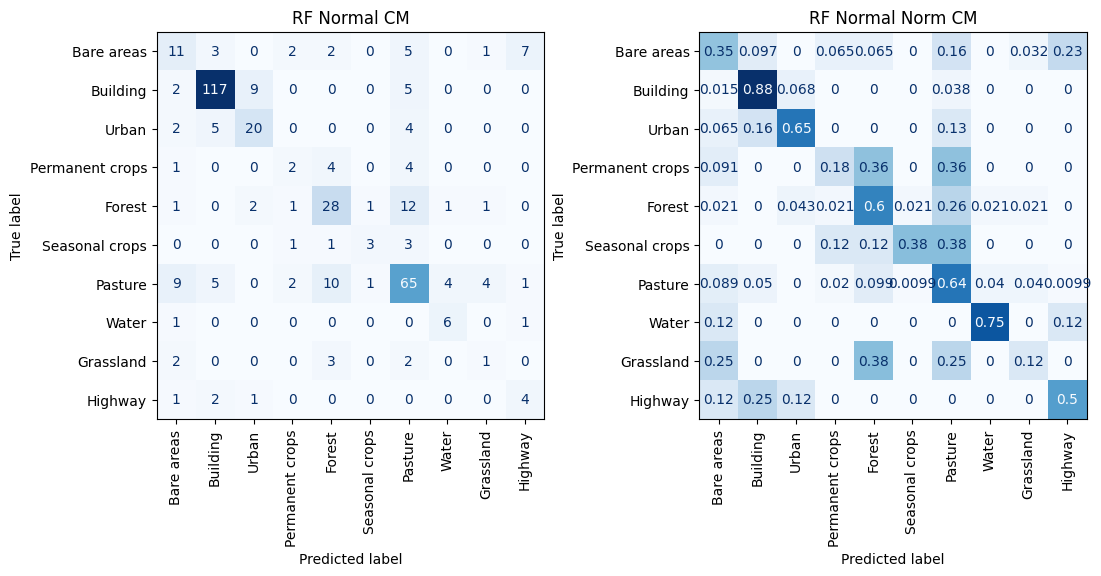

Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 12, 'clf__max_features': 'sqrt', 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 3, 'clf__n_estimators': 153}
Val f1: 0.4827638263613284
Train f1: 0.9112350984098384
Test f1: 0.49327645328969066
                 precision    recall  f1-score   support

     Bare areas       0.37      0.35      0.36        31
       Building       0.89      0.88      0.88       133
         Forest       0.58      0.60      0.59        47
      Grassland       0.14      0.12      0.13         8
        Highway       0.31      0.50      0.38         8
        Pasture       0.65      0.64      0.65       101
Permanent crops       0.25      0.18      0.21        11
 Seasonal crops       0.60      0.38      0.46         8
          Urban       0.62      0.65      0.63        31
          Water       0.55      0.75      0.63         8

       accuracy                           0.67       386
      macro avg    

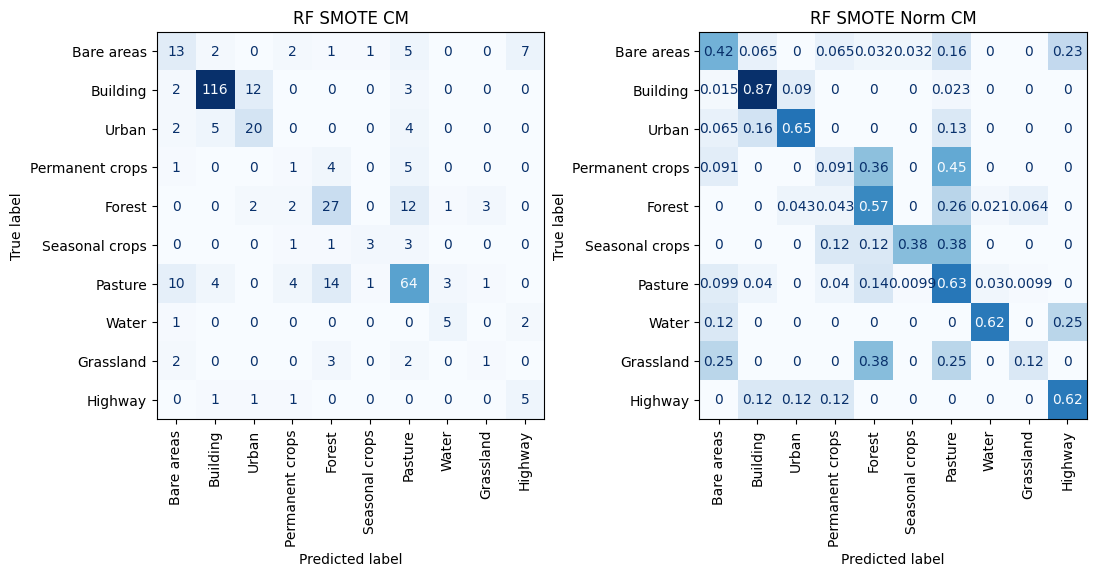

Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 12, 'clf__max_features': 'sqrt', 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 3, 'clf__n_estimators': 153}
Val f1: 0.4662481063916455
Train f1: 0.9152247802572792
Test f1: 0.48632958999458253
                 precision    recall  f1-score   support

     Bare areas       0.42      0.42      0.42        31
       Building       0.91      0.87      0.89       133
         Forest       0.54      0.57      0.56        47
      Grassland       0.20      0.12      0.15         8
        Highway       0.36      0.62      0.45         8
        Pasture       0.65      0.63      0.64       101
Permanent crops       0.09      0.09      0.09        11
 Seasonal crops       0.60      0.38      0.46         8
          Urban       0.57      0.65      0.61        31
          Water       0.56      0.62      0.59         8

       accuracy                           0.66       386
      macro avg    

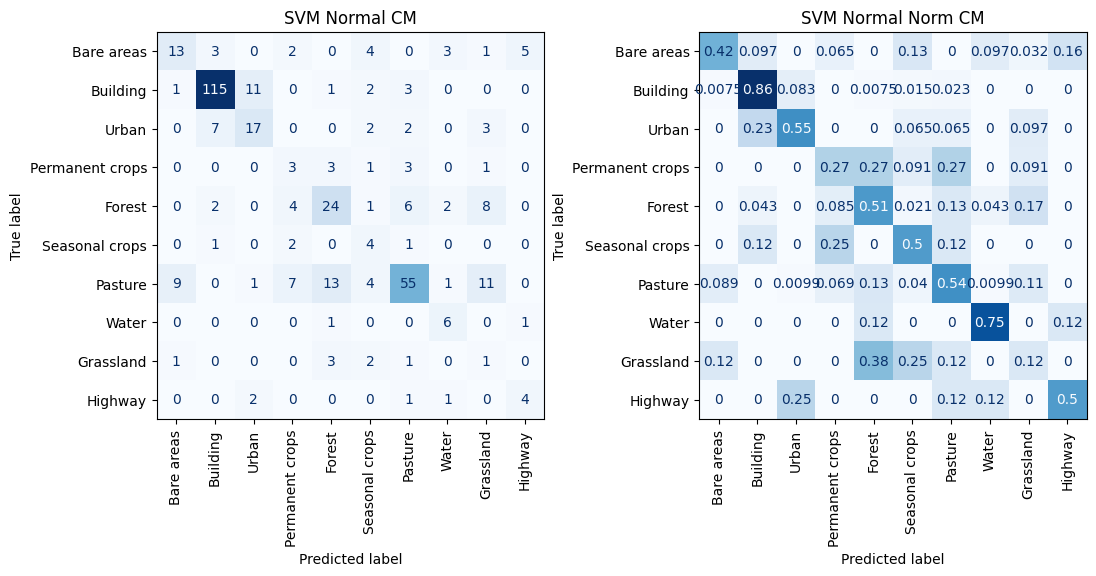

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.45803535625505587
Train f1: 0.7089026805350638
Test f1: 0.4629007617782612
                 precision    recall  f1-score   support

     Bare areas       0.54      0.42      0.47        31
       Building       0.90      0.86      0.88       133
         Forest       0.53      0.51      0.52        47
      Grassland       0.04      0.12      0.06         8
        Highway       0.40      0.50      0.44         8
        Pasture       0.76      0.54      0.64       101
Permanent crops       0.17      0.27      0.21        11
 Seasonal crops       0.20      0.50      0.29         8
          Urban       0.55      0.55      0.55        31
          Water       0.46      0.75      0.57         8

       accuracy                           0.63       386
      macro avg       0.46      0.50      0.46       386
   weighted avg       0.69      0.63      0.65       386


SVM SMOTE

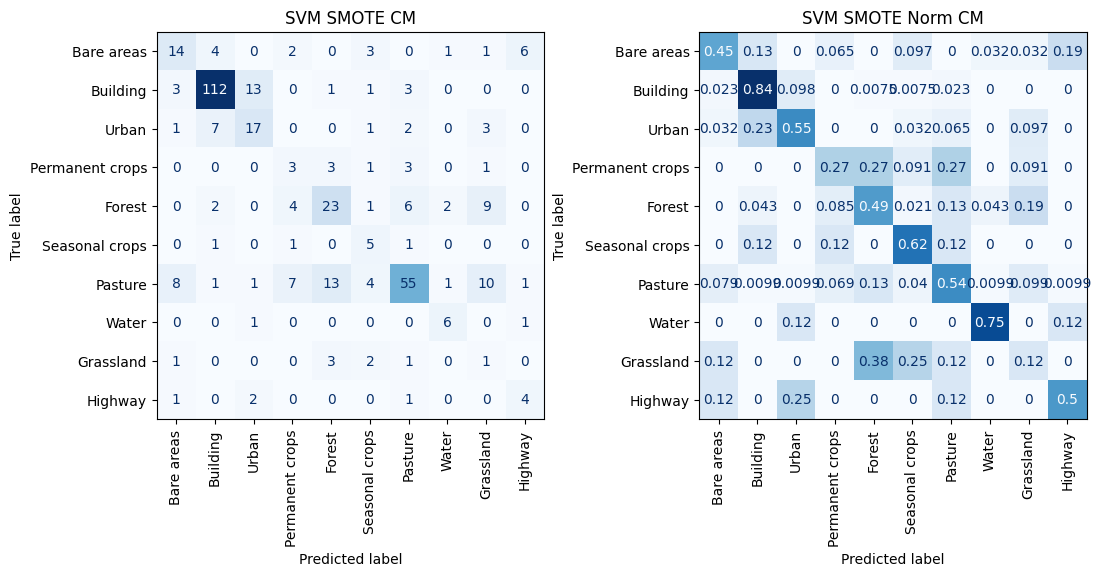

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.4701652494002081
Train f1: 0.7365730371426397
Test f1: 0.473231474337578
                 precision    recall  f1-score   support

     Bare areas       0.50      0.45      0.47        31
       Building       0.88      0.84      0.86       133
         Forest       0.53      0.49      0.51        47
      Grassland       0.04      0.12      0.06         8
        Highway       0.33      0.50      0.40         8
        Pasture       0.76      0.54      0.64       101
Permanent crops       0.18      0.27      0.21        11
 Seasonal crops       0.28      0.62      0.38         8
          Urban       0.50      0.55      0.52        31
          Water       0.60      0.75      0.67         8

       accuracy                           0.62       386
      macro avg       0.46      0.51      0.47       386
   weighted avg       0.68      0.62      0.64       386


Boruta


In [ ]:
exp_group2 = Runner(gdf, 'CODIGO_GROUP_2', features)
exp_group2.load_train_test_data()
exp_group2.run_all_experiments(include_boruta=True)

In [ ]:
# exp_group2.run_rf_normal()

In [ ]:
# exp_group2.run_rf_with_smote()

In [ ]:
# exp_group2.run_svm_normal()

In [ ]:
# exp_group2.run_svm_with_smote()

### Codigo Group 1 

train distribution:
OBSERV_GROUP
Building               532
Agriculture            483
Forest                 342
Artificial Surfaces    154
Water                   32
Name: count, dtype: int64

test distribution:
OBSERV_GROUP
Building               133
Agriculture            121
Forest                  85
Artificial Surfaces     39
Water                    8
Name: count, dtype: int64

RF Normal
Fitting 5 folds for each of 30 candidates, totalling 150 fits


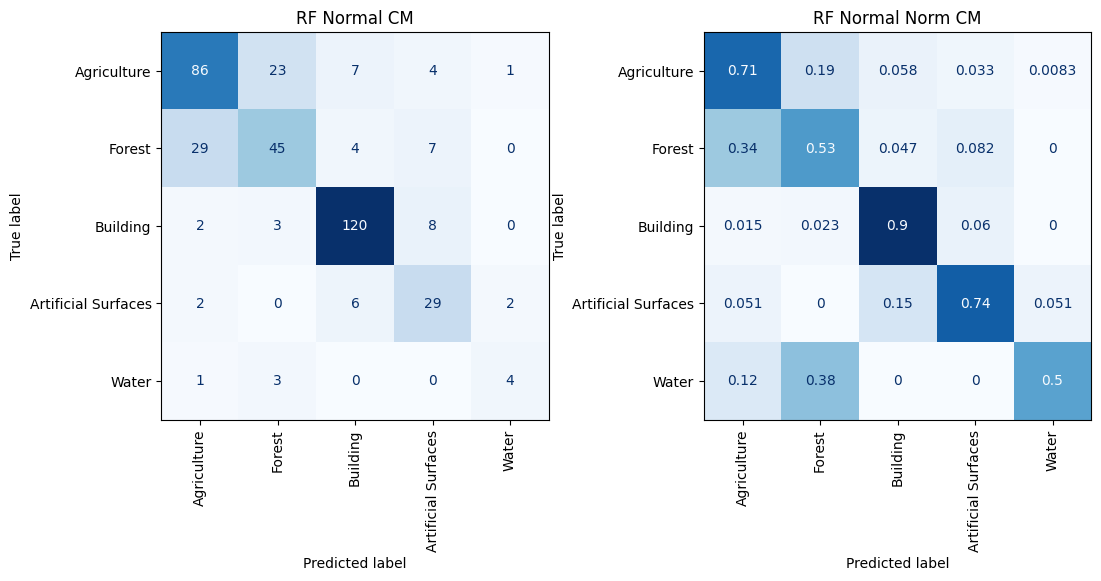

Best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 13, 'clf__n_estimators': 107}
Val f1: 0.6890016553963474
Train f1: 0.9316419291788209
Test f1: 0.6737239141592073
Test f1: 0.6737
                     precision    recall  f1-score   support

        Agriculture       0.72      0.71      0.71       121
Artificial Surfaces       0.60      0.74      0.67        39
           Building       0.88      0.90      0.89       133
             Forest       0.61      0.53      0.57        85
              Water       0.57      0.50      0.53         8

           accuracy                           0.74       386
          macro avg       0.68      0.68      0.67       386
       weighted avg       0.73      0.74      0.73       386


RF SMOTE
Fitting 5 folds for each of 30 candidates, totalling 150 fits


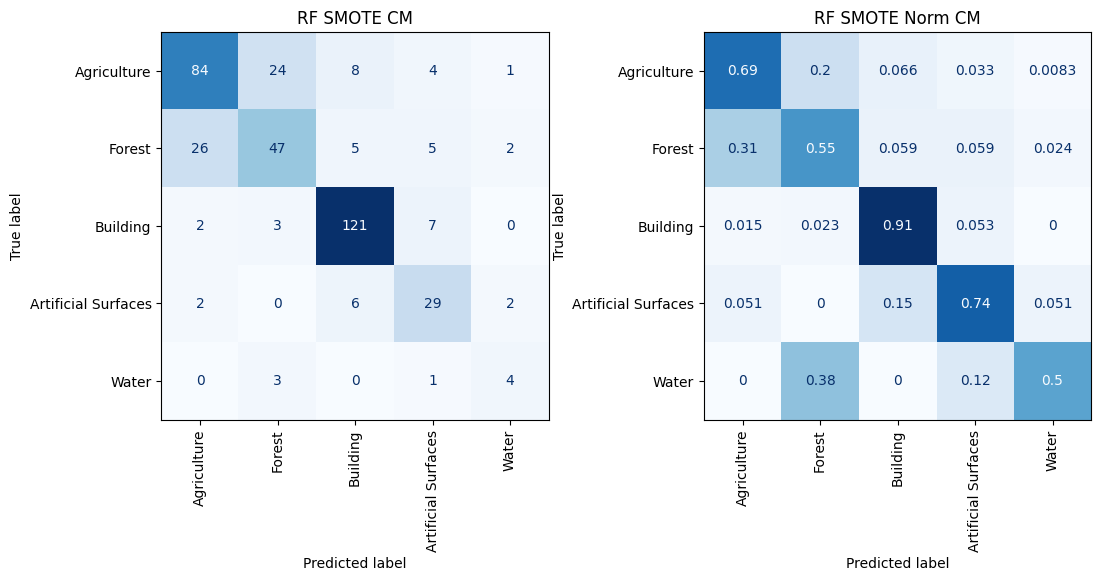

Best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 13, 'clf__n_estimators': 107}
Val f1: 0.6839327862566753
Train f1: 0.9391898206320948
Test f1: 0.6669057187037997
                     precision    recall  f1-score   support

        Agriculture       0.74      0.69      0.71       121
Artificial Surfaces       0.63      0.74      0.68        39
           Building       0.86      0.91      0.89       133
             Forest       0.61      0.55      0.58        85
              Water       0.44      0.50      0.47         8

           accuracy                           0.74       386
          macro avg       0.66      0.68      0.67       386
       weighted avg       0.74      0.74      0.74       386


SVM Normal


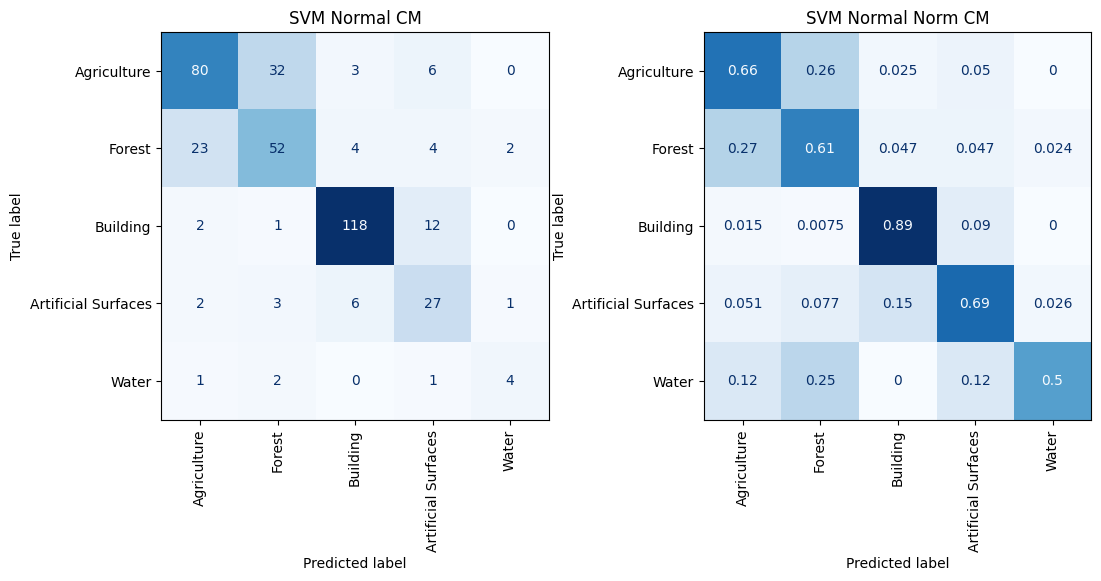

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.6670697907306264
Train f1: 0.8188491986787823
Test f1: 0.6653979941848054
                     precision    recall  f1-score   support

        Agriculture       0.74      0.66      0.70       121
Artificial Surfaces       0.54      0.69      0.61        39
           Building       0.90      0.89      0.89       133
             Forest       0.58      0.61      0.59        85
              Water       0.57      0.50      0.53         8

           accuracy                           0.73       386
          macro avg       0.67      0.67      0.67       386
       weighted avg       0.74      0.73      0.73       386


SVM SMOTE


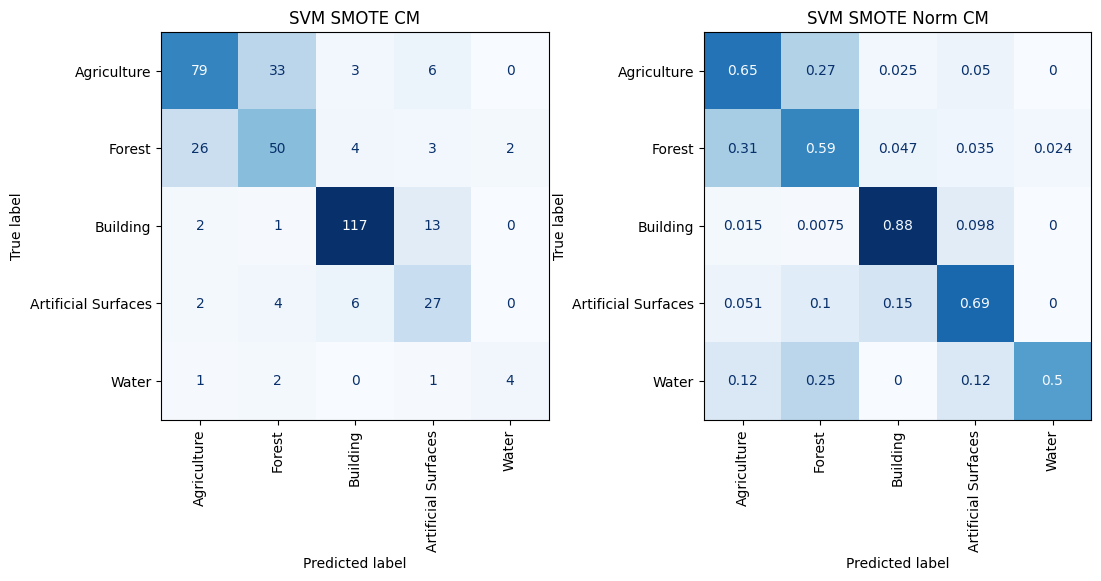

Best params: {'clf__C': 6, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Val f1: 0.6549338528299117
Train f1: 0.82682765063918
Test f1: 0.6646630480355433
                     precision    recall  f1-score   support

        Agriculture       0.72      0.65      0.68       121
Artificial Surfaces       0.54      0.69      0.61        39
           Building       0.90      0.88      0.89       133
             Forest       0.56      0.59      0.57        85
              Water       0.67      0.50      0.57         8

           accuracy                           0.72       386
          macro avg       0.68      0.66      0.66       386
       weighted avg       0.73      0.72      0.72       386


Boruta
Selected: 21/22
Removed: {'solidity'}

RF SMOTE (Boruta)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


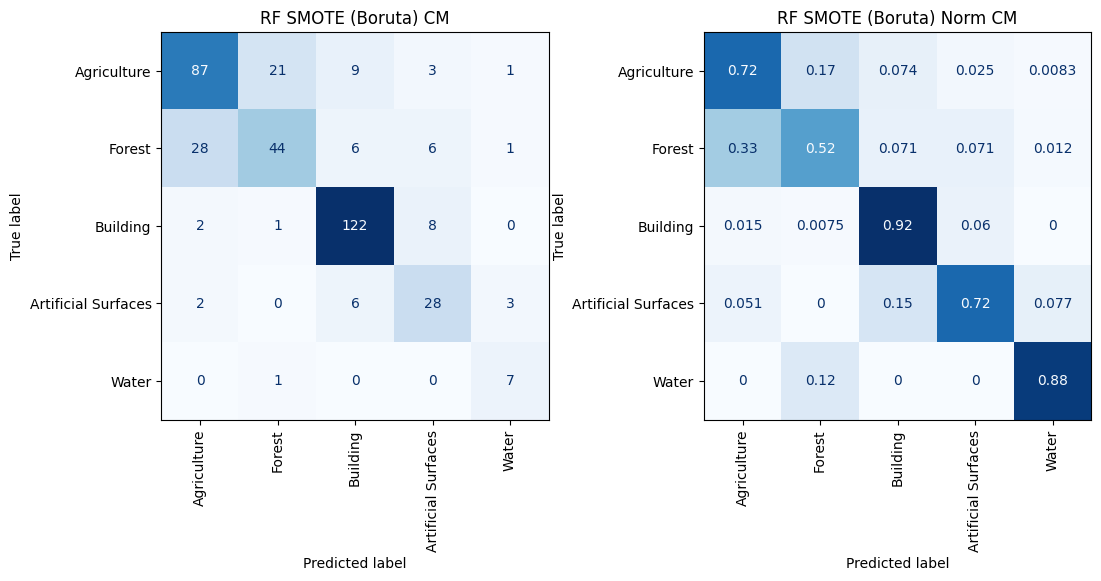

Best params: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__max_leaf_nodes': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 13, 'clf__n_estimators': 107}
Val f1: 0.6803103137766868
Train f1: 0.9407017142435207
Test f1: 0.7109344012204424
                     precision    recall  f1-score   support

        Agriculture       0.73      0.72      0.72       121
Artificial Surfaces       0.62      0.72      0.67        39
           Building       0.85      0.92      0.88       133
             Forest       0.66      0.52      0.58        85
              Water       0.58      0.88      0.70         8

           accuracy                           0.75       386
          macro avg       0.69      0.75      0.71       386
       weighted avg       0.74      0.75      0.74       386



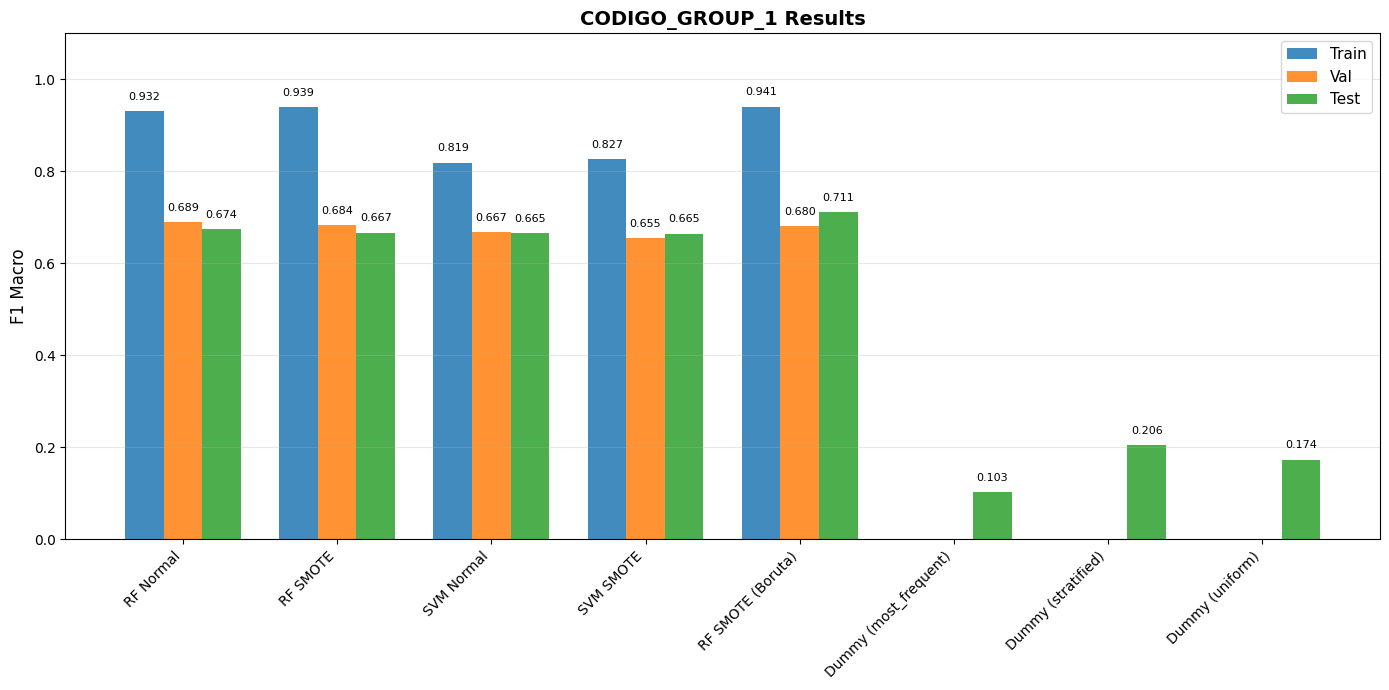

In [ ]:
exp_group1 = Runner(gdf, 'CODIGO_GROUP_1', features)
exp_group1.load_train_test_data()
exp_group1.run_all_experiments(include_boruta=True)

In [ ]:
# exp_group1.run_rf_normal()

In [ ]:
# exp_group1.run_rf_with_smote()

In [ ]:
# exp_group1.run_svm_normal()

In [ ]:
# exp_group1.run_svm_with_smote()